# AI-Based Predictive Maintenance & Mechanical Fault Detection using Optimized Neural Networks

This project focuses on developing and optimizing an Artificial Neural Network (ANN) to detect potential machine failures using industrial sensor data modeled on real milling machine operations.

Instead of comparing multiple models, the primary objective is to deeply explore the capability of neural networks in capturing complex, non-linear relationships between machine parameters such as temperature, rotational speed, torque, and tool wear.

The model is iteratively improved through tuning architecture, hyperparameters, and training strategies to enhance predictive performance and reliability in fault detection scenarios.

**Goal:** Evaluate and maximize the effectiveness of ANN-based approaches for early detection of mechanical faults, enabling smarter maintenance and reduced downtime in industrial systems.

In [1]:
# Importing libraries for data handling, preprocessing, visualization, and building the ANN model
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim

import random
import joblib

In [2]:
# Fix random seeds for reproducibility
seed = 42 
random.seed(seed)                  # Python random module
np.random.seed(seed)               # NumPy
torch.manual_seed(seed)            # PyTorch CPU

## Data Retrival

In [3]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Removing unecessory features
df.drop(columns={'UDI', 'Product ID','TWF', 'HDF', 'PWF', 'OSF', 'RNF'}, inplace = True)

# Renaming features
df.rename(columns = {'Type':'type', 'Air temperature [K]':'air_temp',
       'Process temperature [K]':'process_temp', 'Rotational speed [rpm]':'rotational_speed', 'Torque [Nm]':'torque',
       'Tool wear [min]':'tool_wear_min','Machine failure':'machine_failure'}, inplace = True)
df.head()

,type,air_temp,process_temp,rotational_speed,torque,tool_wear_min,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Exoploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   type              10000 non-null  object 
 1   air_temp          10000 non-null  float64
 2   process_temp      10000 non-null  float64
 3   rotational_speed  10000 non-null  int64  
 4   torque            10000 non-null  float64
 5   tool_wear_min     10000 non-null  int64  
 6   machine_failure   10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


In [6]:
df.describe()

,air_temp,process_temp,rotational_speed,torque,tool_wear_min,machine_failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [7]:
df[['air_temp', 'process_temp', 'rotational_speed', 'torque',
       'tool_wear_min', 'machine_failure']].skew()

air_temp            0.114274
process_temp        0.015027
rotational_speed    1.993171
torque             -0.009517
tool_wear_min       0.027292
machine_failure     5.151852
dtype: float64

### Outlier Detection
We examined all input features for skewness and outliers.  
Features with significant skew or extreme values are:

. Rotational Speed  (right-skewed due to some high-speed points)  
. Torque            (minor outliers at very high values)  
. Tool Wear         (few extreme high values)  
. Machine Failure   (highly imbalanced target)

These features may require clipping, log transformation, scaling, or class weighting to improve ANN performance.

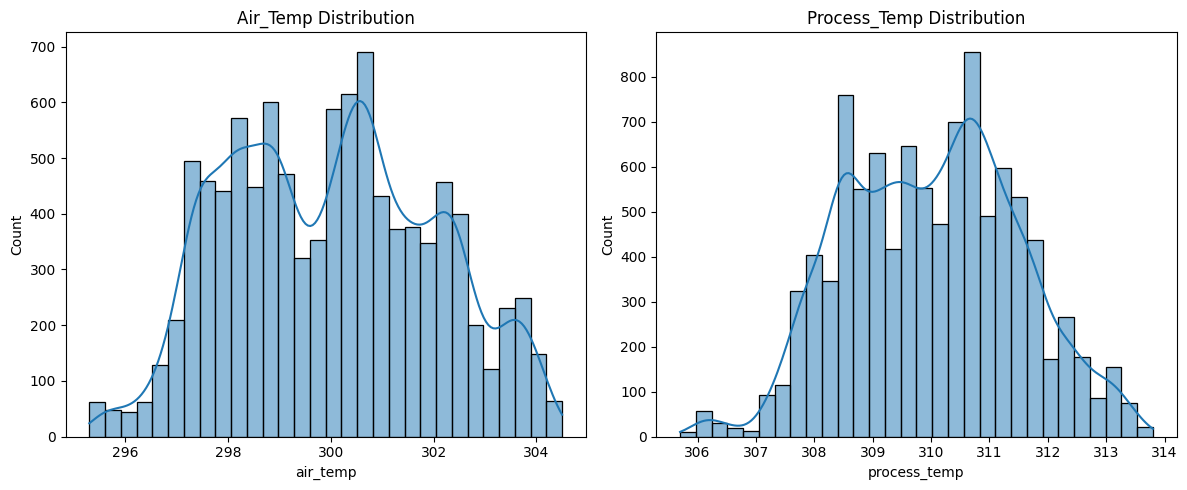

In [8]:
# Checking the normal distribution of air_temp and process_temp features

fig , axes = plt.subplots(1,2 , figsize=(12,5))
sns.histplot(df['air_temp'], kde=True,bins=30 , ax=axes[0])
axes[0].set_title("Air_Temp Distribution")

sns.histplot(df['process_temp'], kde=True,bins=30 , ax=axes[1])
axes[1].set_title("Process_Temp Distribution")

plt.tight_layout()
plt.show()



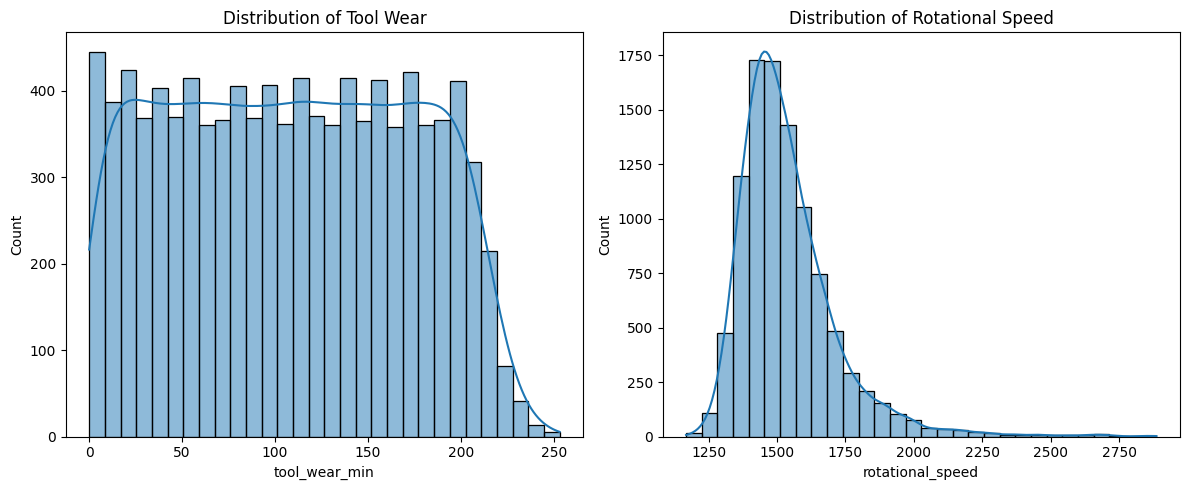

In [9]:
# Visualizing the distribution of tool_wear and rotational_speed
fig, axes = plt.subplots(1,2 , figsize=(12,5))
sns.histplot(df['tool_wear_min'], kde=True, bins=30, ax = axes[0])
axes[0].set_title("Distribution of Tool Wear")

sns.histplot(df['rotational_speed'], kde=True, bins=30, ax = axes[1])
axes[1].set_title("Distribution of Rotational Speed")

plt.tight_layout()
plt.show()

Tool wear shows a flat/boxy histogram because values are spread across a wide usage range rather than clustered, indicating consistent usage levels with few extremes.

Now, we analyze rotational speed and torque using a box plot to identify skewness and potential outliers.

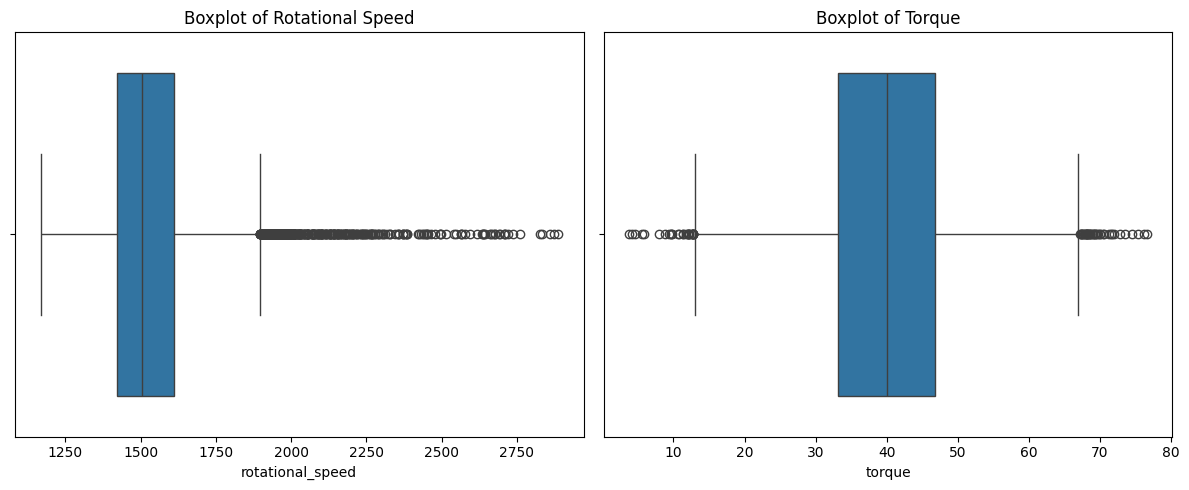

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x = df['rotational_speed'], ax=axes[0])
axes[0].set_title('Boxplot of Rotational Speed')

sns.boxplot(x=df['torque'], ax=axes[1])
axes[1].set_title('Boxplot of Torque')

plt.tight_layout()
plt.show()

Torque shows extreme values on both ends, and rotational speed is right-skewed with high-end outliers. These represent real operating conditions, so outliers are retained. Features will be scaled before training the ANN to stabilize learning

In [11]:
df.columns

Index(['type', 'air_temp', 'process_temp', 'rotational_speed', 'torque',
       'tool_wear_min', 'machine_failure'],
      dtype='object')

In [12]:
# Before encoding
print(df['type'].head())

0    M
1    L
2    L
3    L
4    L
Name: type, dtype: object


### Correlation Analysis
We analyze feature correlations to identify relationships, multicollinearity, and patters with the target variable

In [13]:
df_num = df.drop(columns={'type'})

In [14]:
df_num.corr()['machine_failure'].sort_values(ascending =False)

machine_failure     1.000000
torque              0.191321
tool_wear_min       0.105448
air_temp            0.082556
process_temp        0.035946
rotational_speed   -0.044188
Name: machine_failure, dtype: float64

#### Feature-Target Correlation Analysis
We computed the linear correlation between input features and the target (machine_failure). Most features show low correlation, with torque (0.19) and tool wear (0.11) being the most predictive. Other features such as air temperature (0.08), process temperature (0.03), rotational speed (-0.04), and type (-0.005) exhibit very weak linear relationships. Low linear correlation is expected in engineering datasets, as neural networks can capture complex nonlinear patterns beyond what simple correlation shows.

### Exploring Target Feature (machine_failure)

In [15]:
# Checking value counts
df['machine_failure'].value_counts()

machine_failure
0    9661
1     339
Name: count, dtype: int64

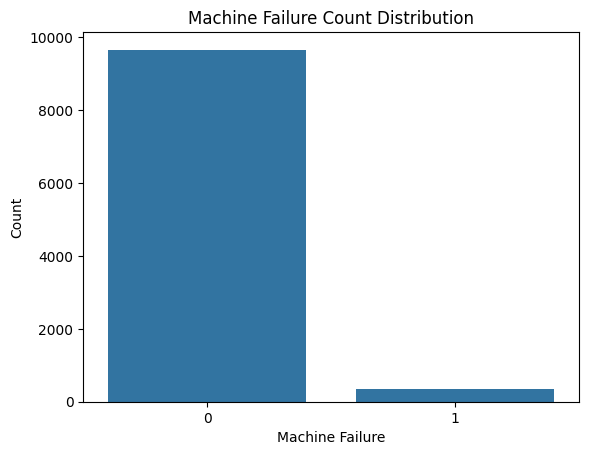

In [16]:
# Count plot for the 'machine_failure' 
sns.countplot(data=df, x='machine_failure')
plt.xlabel('Machine Failure')
plt.ylabel('Count')
plt.title('Machine Failure Count Distribution')

plt.show()

#### Target Distribution

The dataset is highly imbalanced: only ~3.4% of the samples correspond to machine failures (1), while the majority are non-failure (0). This imbalance will be considered during model training to avoid bias toward the majority class.

## Data Preprocessing

In [17]:
# Label encoding the 'Type' column to convert categories L, M, H into numeric values
# Before encoding
print("Before encoding:")
print(df['type'].head())

# Initialize encoder
le = LabelEncoder()

# Fit and transform the 'Type' column
df['type_encoded'] = le.fit_transform(df['type'])

# After encoding
print("\nAfter encoding:")
print(df[['type', 'type_encoded']].head())

Before encoding:
0    M
1    L
2    L
3    L
4    L
Name: type, dtype: object

After encoding:
  type  type_encoded
0    M             2
1    L             1
2    L             1
3    L             1
4    L             1


In [18]:
# Define features and target
feature_cols = ['air_temp', 'process_temp', 'rotational_speed', 'torque', 'tool_wear_min']
target_col = 'machine_failure'

X = df[feature_cols]
y = df[target_col]

In [19]:
# Scale numeric features (all inputs) for ANN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Data Prepration and Defining Model

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y, test_size=0.2, random_state=42)

In [21]:
# Converting to Tensors
X_train_tensor = torch.tensor(X_train, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32)

In [22]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.features)
    def __getitem__(self,idx):
        return self.features[idx],self.labels[idx] 

In [23]:
train_dataset = CustomDataset(X_train_tensor,y_train_tensor)
test_dataset = CustomDataset(X_test_tensor,y_test_tensor)

In [24]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [25]:
# Defining nn class
class MYNN(nn.Module):
     def __init__(self,features):
         super().__init__()
         self.model = nn.Sequential(
             nn.Linear(features,32),
             nn.ReLU(),
             nn.Linear(32,16),
             nn.ReLU(),
             nn.Linear(16,8),
             nn.ReLU(),
             nn.Linear(8,1)
         )
     def forward(self,X):
         return self.model(X)
     

## Model Training

In [26]:
epochs = 100
lr =0.001

In [27]:
# Instatiate the model
model = MYNN(X_train.shape[1])

# Loss criterion
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

In [28]:
# Calculate class weights
num_zeros = (y == 0).sum()
num_ones = (y == 1).sum()

pos_weight = torch.tensor([num_zeros / num_ones], dtype=torch.float32)

# Use weighted loss
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [29]:
# Training loop
for epoch in range(epochs):
    total_loss = 0
    for batch_features, batch_labels in train_loader:
        batch_labels = batch_labels.view(-1, 1).float()   
        
        outputs = model(batch_features)

        loss = criterion(outputs, batch_labels)
        
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        
        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader)
    
    print(f'Epoch: {epoch+1}, Loss: {avg_loss}')

Epoch: 1, Loss: 1.0936473635435104
Epoch: 2, Loss: 0.7219637858271599
Epoch: 3, Loss: 0.6324440749287605
Epoch: 4, Loss: 0.5857734917998314
Epoch: 5, Loss: 0.558149703681469
Epoch: 6, Loss: 0.5274710575640201
Epoch: 7, Loss: 0.506940578788519
Epoch: 8, Loss: 0.49530095809698105
Epoch: 9, Loss: 0.4843954881131649
Epoch: 10, Loss: 0.4870069749951363
Epoch: 11, Loss: 0.47156444418430327
Epoch: 12, Loss: 0.4568818809688091
Epoch: 13, Loss: 0.4669749084711075
Epoch: 14, Loss: 0.4519873580634594
Epoch: 15, Loss: 0.4424723462164402
Epoch: 16, Loss: 0.4289735914468765
Epoch: 17, Loss: 0.42974046009778977
Epoch: 18, Loss: 0.4227666980177164
Epoch: 19, Loss: 0.4097436078488827
Epoch: 20, Loss: 0.4061595377922058
Epoch: 21, Loss: 0.3998509594798088
Epoch: 22, Loss: 0.39085185472667217
Epoch: 23, Loss: 0.3823010899871588
Epoch: 24, Loss: 0.37358189532160757
Epoch: 25, Loss: 0.37823793387413024
Epoch: 26, Loss: 0.37119842354953286
Epoch: 27, Loss: 0.3636587299108505
Epoch: 28, Loss: 0.3615997867137

## Model Evaluation

In [30]:
with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.sigmoid(outputs)        # convert logits → probability
    preds = (probs >= 0.5).int()          # threshold 0.5 → 0 or 1

In [31]:
correct = (preds.view(-1) == y_test_tensor).sum().item()
accuracy = correct / len(y_test_tensor)
print(f'Test Accuracy: {accuracy*100:.2f}%')

Test Accuracy: 93.75%


In [32]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_tensor.numpy(), preds.view(-1).numpy()))
    
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_tensor.numpy(), preds.view(-1).numpy()))
    
# ROC-AUC Score
roc_score = roc_auc_score(y_test_tensor.numpy(), probs.numpy())
print(f"ROC-AUC Score: {roc_score:.4f}")

Confusion Matrix:
[[1823  116]
 [   9   52]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97      1939
         1.0       0.31      0.85      0.45        61

    accuracy                           0.94      2000
   macro avg       0.65      0.90      0.71      2000
weighted avg       0.97      0.94      0.95      2000

ROC-AUC Score: 0.9513


## Conclusion

This project demonstrates the successful development of a predictive maintenance system using an Artificial Neural Network, capable of identifying machine failure patterns from operational data with high reliability.

### Key Takeaways

1. High performance: Achieved 93.7% accuracy with ROC-AUC of 0.9513, demonstrating excellent predictive capability.
2. Imbalance-aware modeling: Maintained high recall (0.85) for failure detection, ensuring critical events are not missed.
3. End-to-end workflow: Covered preprocessing, feature engineering, model training, and evaluation.
4. Real-world relevance: Illustrates how AI can enable proactive maintenance decisions in industrial systems.

This work showcases the ability to build, evaluate, and optimize AI solutions for real-world engineering problems, combining technical depth with practical impact — a strong foundation for deploying predictive maintenance systems in production.

### Save Final Model

In [33]:
# save full pipeline (preprocessing + RF model)
torch.save(model.state_dict(), "ann_model.pth")